# Support Vector Machines (SVM)

## Linear SVM

In [1]:
DEBUG = True #sebug mode, do not use all data since SVM takes too long

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
from train_validation_split import splitTrainingValidation
from load_dataset import loadDataSet


SVMPath = './models/SVM'
if not SVMPath in sys.path:
    sys.path.append(SVMPath)

import SVM_linear, SVM_nonlinear

filename = "dataset/trainData.txt"
D, L = loadDataSet(filename, numFeatures=6)
"""
if DEBUG:
    # Use only a subset of the data for debugging
    D = D[:, :100]
    L = L[:100]
"""

(DTR, LTR), (DVAL, LVAL) = splitTrainingValidation(2.0/3.0, D, L)


print(f"DTR shape: {DTR.shape}")
print(f"DVAL shape: {DVAL.shape}")
print(f"LTR shape: {LTR.shape}")
print(f"LVAL shape: {LVAL.shape}")

DTR shape: (6, 4000)
DVAL shape: (6, 2000)
LTR shape: (4000,)
LVAL shape: (2000,)


We train and fit linear SVM, using $K = 1.0$ and different values of $C$. We then plot $\text{min DCF}$ and $\text{DCF}$ as functions of $C$.

In [3]:
from joblib import Parallel, delayed #for parallel processing

### Linear SVM, $K = 1.0$, different values of $C$, usual application $\left( \pi_T = 0.1, 1.0, 1.0 \right)$ - **Uncentered data**

In [4]:
def SVM_linear_pipeline(DTR, LTR, DVAL, LVAL):

    def train_single_svm(C_test, K_test, DTR, LTR, DVAL, LVAL, appPriorTrue):
        """
        Trains a single SVM with the given parameters and returns the results.
        This function is a wrapper for the real SVM training function to allow parallel execution.
        """
        print(f"Training SVM with C = {C_test:.5f}...")
        
        #real SVM training function
        bestW, bestB, minDCF, DCF, errorRate, primal, dual, dualitygap = SVM_linear.fit_SVM_Linear_SoftMargin(
            DTR, LTR, DVAL, LVAL, C_test, K_test, appPriorTrue
        )
        
        print(f"Tested SVM_Linear_SoftMargin with C = {C_test}, K = {K_test}, minDCF = {minDCF}, DCF = {DCF}, errorRate = {errorRate}")
        

        return K_test, C_test, minDCF, DCF, errorRate, primal, dual, dualitygap


    C_values = np.logspace(-5, 0, 11)
    K_test = 1.0  # Fixed kernel parameter
    appPriorTrue = 0.1


    #parallelize the training of SVMs for different C values
    #n_jobs=-1 means using all available CPU cores
    results = Parallel(n_jobs=-1, verbose=10)(
        delayed(train_single_svm)(
            C_test_value, K_test, DTR, LTR, DVAL, LVAL, appPriorTrue
        ) for C_test_value in C_values
    )


    unpacked_results = zip(*results)
    K_table, C_table, minDCF_table, DCFs_table, errorRate_table, \
    primal_loss_table, dual_loss_table, dualitygap_table = unpacked_results


    table_data = []
    for i in range(len(K_table)):
        table_data.append([K_table[i], f"{C_table[i]:.2e}", f"{primal_loss_table[i]:.2e}", f"{-dual_loss_table[i]:.2e}", round(dualitygap_table[i], 4), f"{errorRate_table[i] * 100:.2f}%", round(minDCF_table[i], 4), round(DCFs_table[i], 4)])


    return table_data, C_table, minDCF_table, DCFs_table

if not DEBUG: table_data, C_table, minDCF_table, DCFs_table = SVM_linear_pipeline(DTR, LTR, DVAL, LVAL)

In [5]:
if not DEBUG:
    fig, ax = plt.subplots()
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=table_data, colLabels=['K', 'C', 'Primal Loss', '|Dual Loss|', 'Duality Gap', 'Error Rate', 'minDCF($\pi_T = 0.1$)', 'DCF($\pi_T = 0.1$)'], loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(32)
    table.scale(10, 5)
    plt.title('Linear Soft Margin SVM (uncentered data)\nHyperparams: C $\in$ logspace(-3, 2, 11)', fontsize=45, pad=280)
    plt.show()

In [6]:
if not DEBUG:
    #plot minDCF, actDCF vs C
    plt.figure(figsize=(10, 6))
    plt.plot(C_table, minDCF_table, label='minDCF', marker='o')
    plt.plot(C_table, DCFs_table, label='actDCF', marker='x')
    plt.xscale('log')
    plt.xlabel('C (log scale)', fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.ylim(0, 1.1)
    plt.ylabel('minDCF and actDCF', fontsize=14)
    plt.title('minDCF and actDCF vs C', fontsize=16)

### Linear SVM, $K = 1.0$, different values of $C$, usual application $\left( \pi_T = 0.1, 1.0, 1.0 \right)$ - **centered data**

In [7]:
from mean_covariance import compute_mu_C

if not DEBUG:
    mu_DTR, _ = compute_mu_C(DTR)

    DTR_centered = DTR - mu_DTR

    # Train SVM with centered data
    table_data, C_table, minDCF_table, DCFs = SVM_linear_pipeline(DTR_centered, LTR, DVAL, LVAL)

    #plot minDCF, actDCF vs C
    plt.figure(figsize=(10, 6))
    plt.plot(C_table, minDCF_table, label='minDCF', marker='o')
    plt.plot(C_table, DCFs_table, label='actDCF', marker='x')
    plt.xscale('log')
    plt.xlabel('C (log scale)', fontsize=14)
    plt.legend(fontsize=14)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.ylim(0, 1.1)
    plt.ylabel('minDCF and actDCF', fontsize=14)
    plt.title('minDCF and actDCF vs C', fontsize=16)

## Kernel (Non Linear) SVM

### 1) Polynomial Kernel $k(\mathbf{x}_1, \mathbf{x}_2) = (\mathbf{x}_1^T \mathbf{x}_2 +c)^d$

We now consider the polynomial kernel. For simplicity, we consider only the kernel with $d = 2$, $c = 1$ (but
better results may be possible with different configurations), and we set $\xi = K^2 = 0$, since the kernel already
implicitly accounts for the bias term (due to $c = 1$). We also consider only the original, **non-centered**
features (again, different pre-processing strategies may lead to better results).

In [8]:
def train_single_svm_kernel(C_test, K_test, DTR, LTR, DVAL, LVAL, appPriorTrue, kernel):
    """
    Trains a single SVM with the given parameters and returns the results.
    This function is a wrapper for the real SVM training function to allow parallel execution.
    """
    print(f"Training SVM with C = {C_test:.5f}...")
    
    #real SVM training function
    bestAlpha_hat, minDCF, DCF, errorRate, primal_loss, dual_loss, dualitygap, _ = SVM_nonlinear.fit_SVM_Kernel_SoftMargin(
        DTR, LTR, DVAL, LVAL, C_test, kernel, K_test, appPriorTrue)
    print(f"Tested SVM_Kernel_SoftMargin with K = {K_test}, minDCF = {minDCF}, DCF = {DCF}, errorRate = {errorRate}")
    
    

    return K_test, C_test, minDCF, DCF, errorRate, primal_loss, dual_loss, dualitygap


C_values = np.logspace(-5, 0, 11)
K_test = 0  # xi = K^2 = 0
appPriorTrue = 0.1


#parallelize the training of SVMs for different C values
#n_jobs=-1 means using all available CPU cores
poly_kernel_2_1 = SVM_nonlinear.get_poly_kernel_function(2.0, 1.0)
results = Parallel(n_jobs=-1, verbose=10)(
    delayed(train_single_svm_kernel)(
        C_test_value, K_test, DTR, LTR, DVAL, LVAL, appPriorTrue, kernel=poly_kernel_2_1
    ) for C_test_value in C_values
)


unpacked_results = zip(*results)
K_table, C_table, minDCF_table, DCFs_table, errorRate_table, \
primal_loss_table, dual_loss_table, dualitygap_table = unpacked_results


table_data = []
for i in range(len(K_table)):
    table_data.append([K_table[i], f"{C_table[i]:.2e}", f"{primal_loss_table[i]:.2e}", f"{-dual_loss_table[i]:.2e}", round(dualitygap_table[i], 4), f"{errorRate_table[i] * 100:.2f}%", round(minDCF_table[i], 4), round(DCFs_table[i], 4)])


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   2 out of  11 | elapsed:    7.7s remaining:   34.9s
[Parallel(n_jobs=-1)]: Done   4 out of  11 | elapsed:   19.6s remaining:   34.4s
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:   36.0s remaining:   30.0s
[Parallel(n_jobs=-1)]: Done   8 out of  11 | elapsed:  1.1min remaining:   23.6s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:  3.5min finished


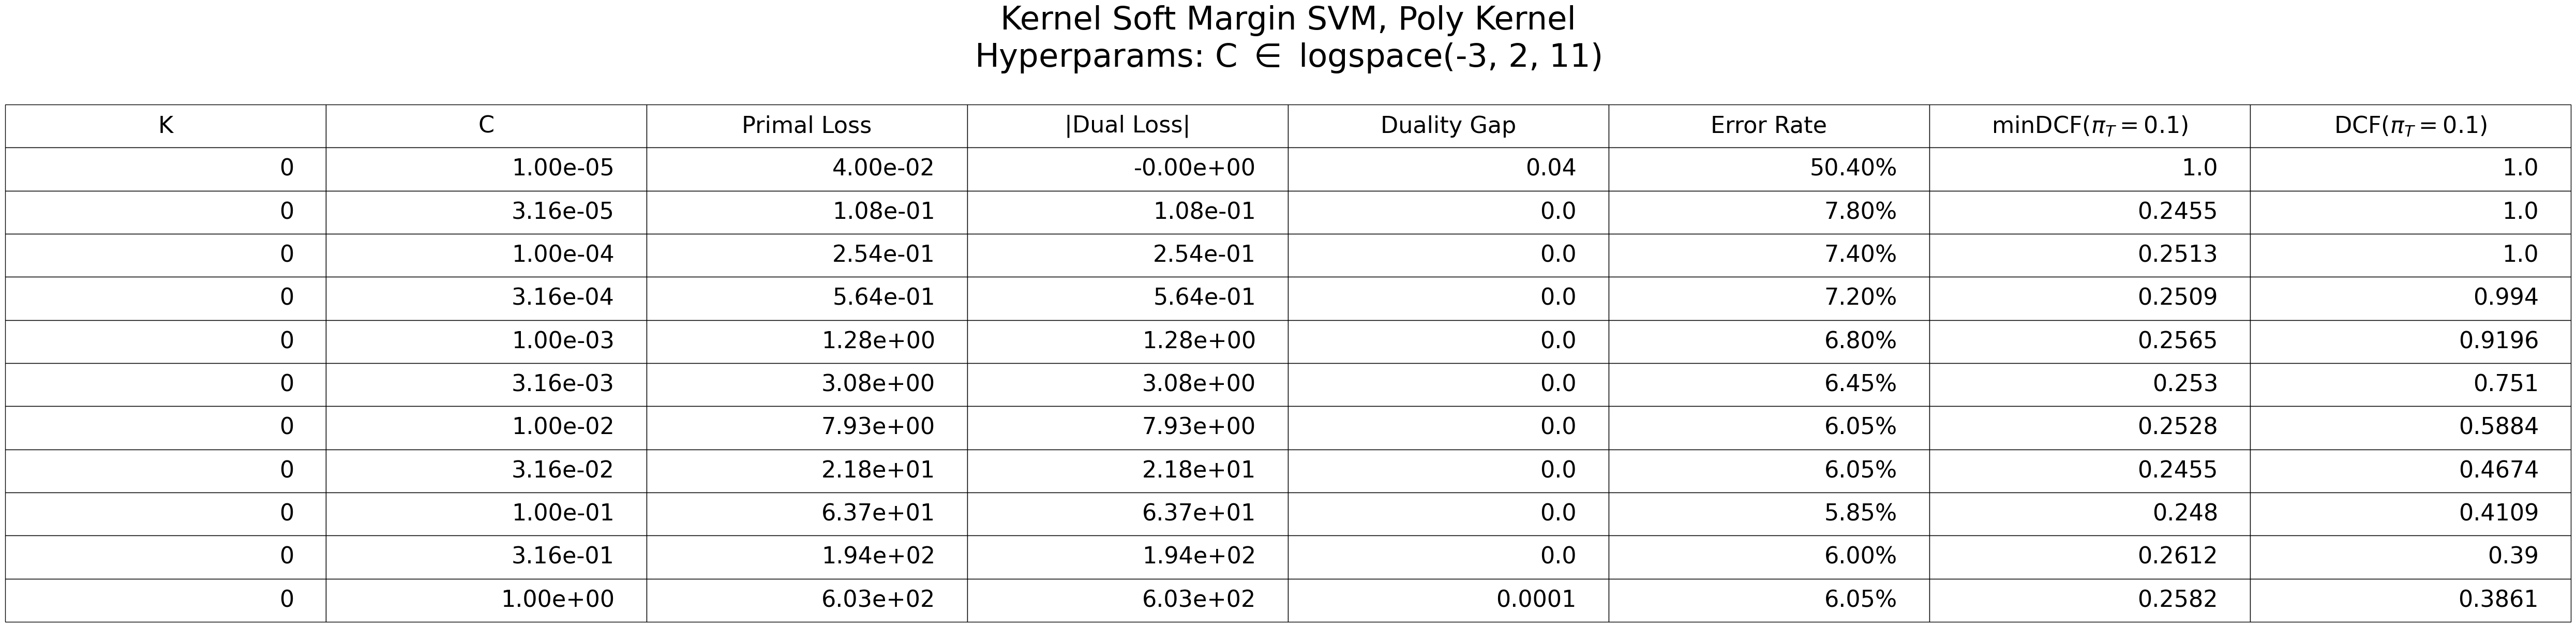

In [9]:
fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=['K', 'C', 'Primal Loss', '|Dual Loss|', 'Duality Gap', 'Error Rate', 'minDCF($\pi_T = 0.1$)', 'DCF($\pi_T = 0.1$)'], loc='center')
table.auto_set_font_size(False)
table.set_fontsize(32)
table.scale(10, 5)
plt.title('Kernel Soft Margin SVM, Poly Kernel\nHyperparams: C $\in$ logspace(-3, 2, 11)', fontsize=45, pad=280)
plt.show()

Text(0.5, 1.0, 'minDCF and actDCF vs C')

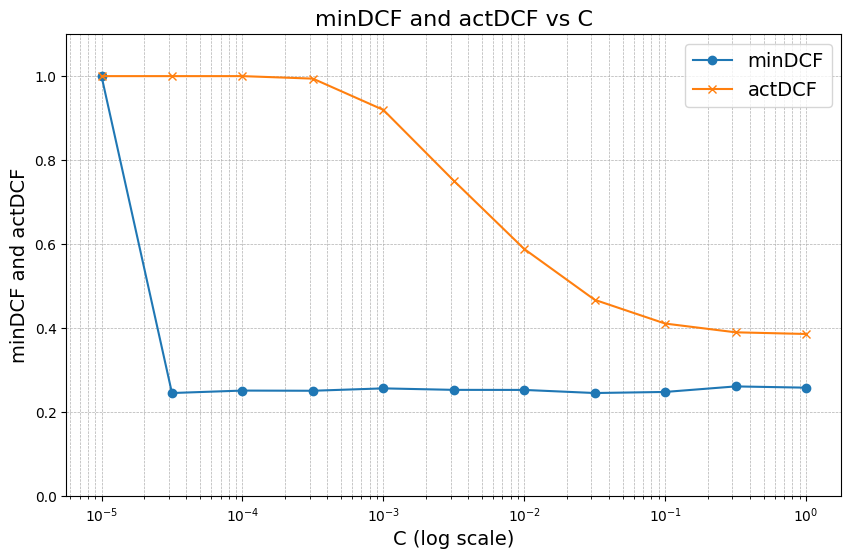

In [10]:

#plot minDCF, actDCF vs C
plt.figure(figsize=(10, 6))
plt.plot(C_table, minDCF_table, label='minDCF', marker='o')
plt.plot(C_table, DCFs_table, label='actDCF', marker='x')
plt.xscale('log')
plt.xlabel('C (log scale)', fontsize=14)
plt.legend(fontsize=14)
plt.ylim(0, 1.1)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylabel('minDCF and actDCF', fontsize=14)
plt.title('minDCF and actDCF vs C', fontsize=16)

### 2) RBF Kernel $k(\mathbf{x}_1, \mathbf{x}_2) = e^{- \gamma \| \mathbf{x}_1 - \mathbf{x}_2 \|^2}$

For RBF kernel we need to optimize both $\gamma$ and $C$ (since the RBF kernel does not implicitly account
for the bias term we set $\xi = K^2 = 1$). Being this two hyperparameters independent, we adopt a **grid search approach**, i.e., we consider different values
of $\gamma$ and different values of $C$, and try all possible combinations. Then we plot $\text{DCF}$ and $\text{min DCF}$ as a function of $C$, like before but sith separate lines for different values of $\gamma$.

In [11]:
gamma_values_numeric = np.array([np.exp(-4), np.exp(-3), np.exp(-2), np.exp(-1)])
gamma_labels_pretty = ['e⁻⁴', 'e⁻³', 'e⁻²', 'e⁻¹']
gamma_label_dict = dict(zip(gamma_values_numeric, gamma_labels_pretty))
print(f"gamma_label_dict: {gamma_label_dict}")

gamma_label_dict: {0.01831563888873418: 'e⁻⁴', 0.049787068367863944: 'e⁻³', 0.1353352832366127: 'e⁻²', 0.36787944117144233: 'e⁻¹'}


In [12]:
%load_ext autoreload

In [13]:
%autoreload 2

In [14]:
import itertools

def train_single_svm_rbf(params, DTR, LTR, DVAL, LVAL, appPriorTrue):
    """
    Trains a single SVM with the given RBF kernel parameters params = (gamma, c) and returns the results.
    """
    #params is a tuple (gamma, C). Unpack them
    gamma_test, C_test = params  
    K_test = 1.0 #xi = 1 fixed
    
    print(f"Testing gamma: {gamma_test:.2e}, C: {C_test:.2e}...")

    #get the RBF kernel function with the given gamma
    kernel_func = SVM_nonlinear.get_rbf_kernel_function(gamma_test)


    #real SVM training function
    bestAlpha, minDCF, DCF, errorRate, primal_loss, dual_loss, dualitygap, scores = SVM_nonlinear.fit_SVM_Kernel_SoftMargin(
        DTR, LTR, DVAL, LVAL, C_test, kernel=kernel_func, K=K_test, appPriorTrue=appPriorTrue
    )
    
    print(f"  -> Completed gamma: {gamma_test:.2e}, C: {C_test:.2e}), minDCF: {minDCF:.4f}")

    
    return gamma_test, K_test, C_test, minDCF, DCF, errorRate, primal_loss, dual_loss, dualitygap, scores


C_values = np.logspace(-3, 2, 11)
gamma_values = [np.exp(-4), np.exp(-3), np.exp(-2), np.exp(-1)]
K_test = 1.0  # xi = K^2 = 0
appPriorTrue = 0.1


#parallelize the training of SVMs for different C values
#n_jobs=-1 means using all available CPU cores
#since here qwe have two hyperparameters (gamma and C), we can construct a grid
param_grid = list(itertools.product(gamma_values, C_values))
print(f"Grid Search: {len(param_grid)} combinations of (gamma, C) to test.")

results = Parallel(n_jobs=-1, verbose=10)(
    delayed(train_single_svm_rbf)(
        params, DTR, LTR, DVAL, LVAL, appPriorTrue
    ) for params in param_grid
)



unpacked_results = zip(*results)
gamma_table, K_table, C_table, minDCF_table, DCFs_table, errorRate_table, \
primal_loss_table, dual_loss_table, dualitygap_table, scoresList = unpacked_results

table_data = []
for i in range(len(C_table)):
    table_data.append([
        gamma_label_dict[gamma_table[i]], 
        K_table[i], 
        f"{C_table[i]:.2e}", 
        f"{primal_loss_table[i]:.2e}", 
        f"{-dual_loss_table[i]:.2e}", 
        round(dualitygap_table[i], 4), 
        f"{errorRate_table[i] * 100:.2f}%", 
        round(minDCF_table[i], 4), 
        round(DCFs_table[i], 4)
    ])


Grid Search: 44 combinations of (gamma, C) to test.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done  18 out of  44 | elapsed:  3.4min remaining:  4.9min
[Parallel(n_jobs=-1)]: Done  23 out of  44 | elapsed:  4.7min remaining:  4.3min
[Parallel(n_jobs=-1)]: Done  28 out of  44 | elapsed:  6.2min remaining:  3.6min
[Parallel(n_jobs=-1)]: Done  33 out of  44 | elapsed:  7.9min remaining:  2.6min
[Parallel(n_jobs=-1)]: Done  38 out of  44 | elapsed: 11.1min remaining:  1.8min
[Parallel(n_jobs=-1)]: Done  44 out of  44 | elapsed: 14.0min finished


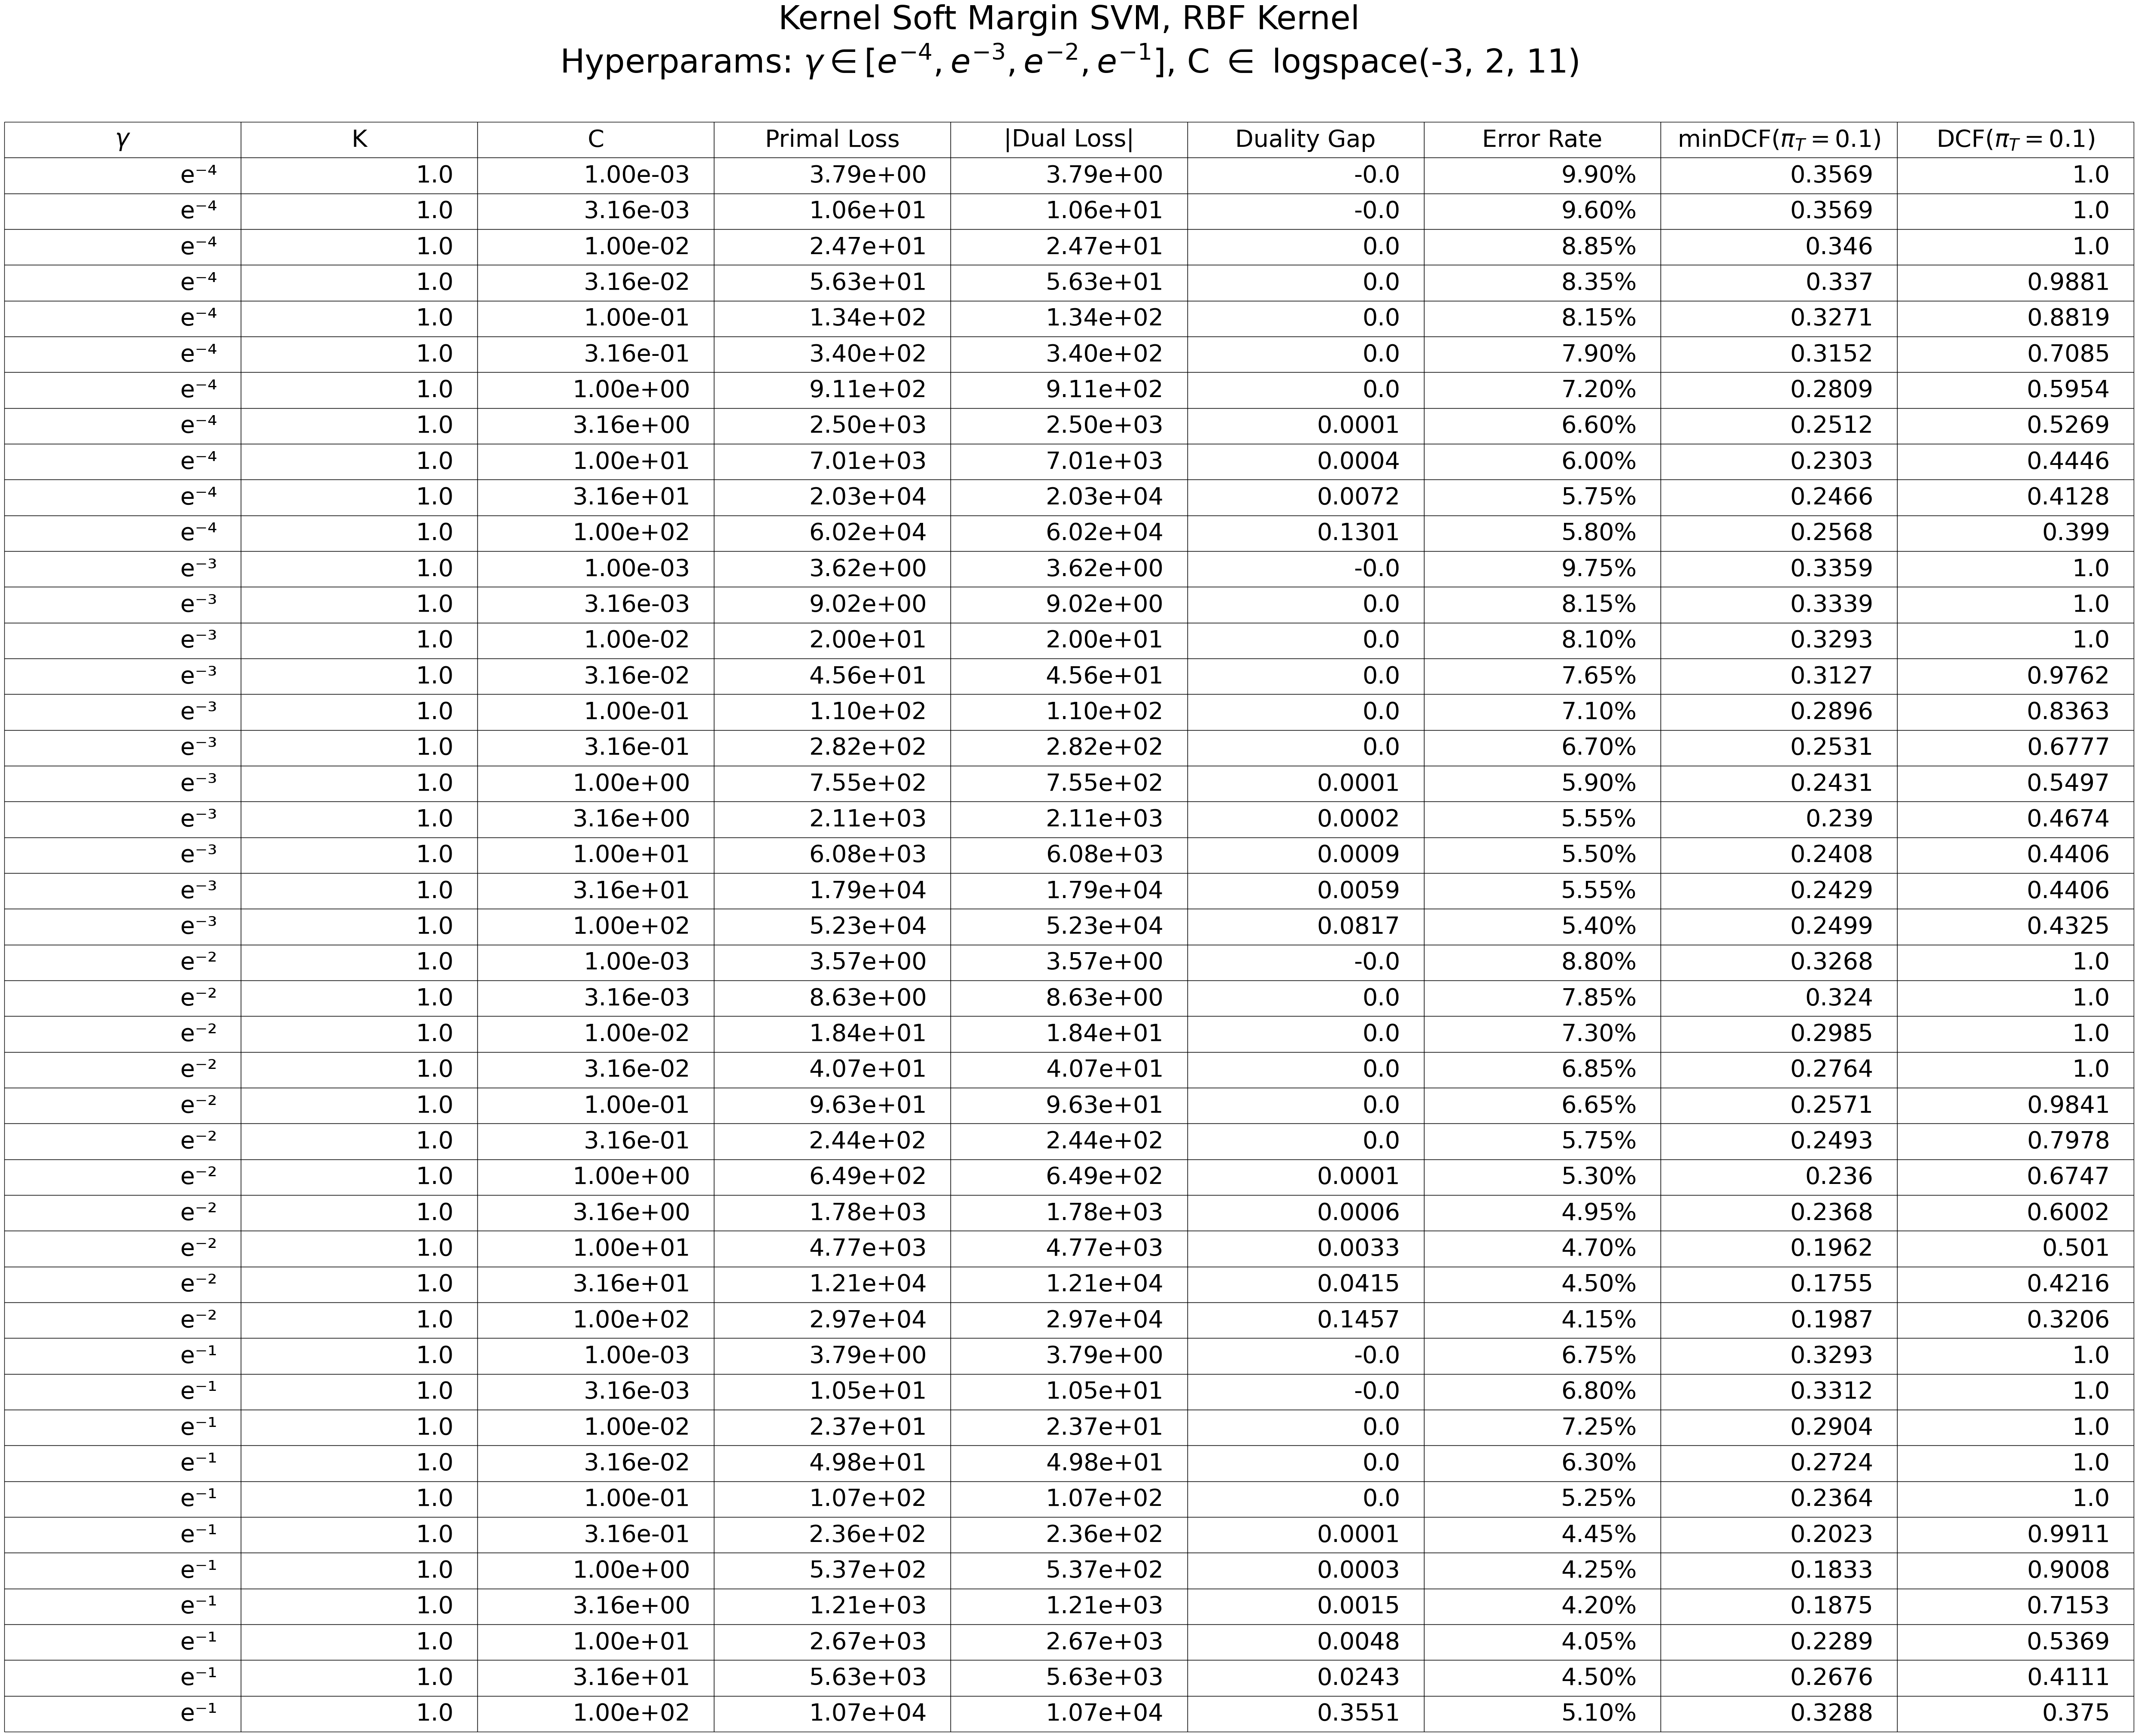

In [ ]:
fig, ax = plt.subplots()
ax.axis('tight')
ax.axis('off')
table = ax.table(cellText=table_data, colLabels=['$\gamma$', 'K', 'C', 'Primal Loss', '|Dual Loss|', 'Duality Gap', 'Error Rate', 'minDCF($\pi_T = 0.1$)', 'DCF($\pi_T = 0.1$)'], loc='center')
table.auto_set_font_size(False)
table.set_fontsize(40)
table.scale(10, 5)
plt.title('Kernel Soft Margin SVM, RBF Kernel\nHyperparams: $\gamma \in [e^{-4}, e^{-3}, e^{-2}, e^{-1}]$, C $\in$ logspace(-3, 2, 11)', fontsize=55, pad=1300)
plt.show()

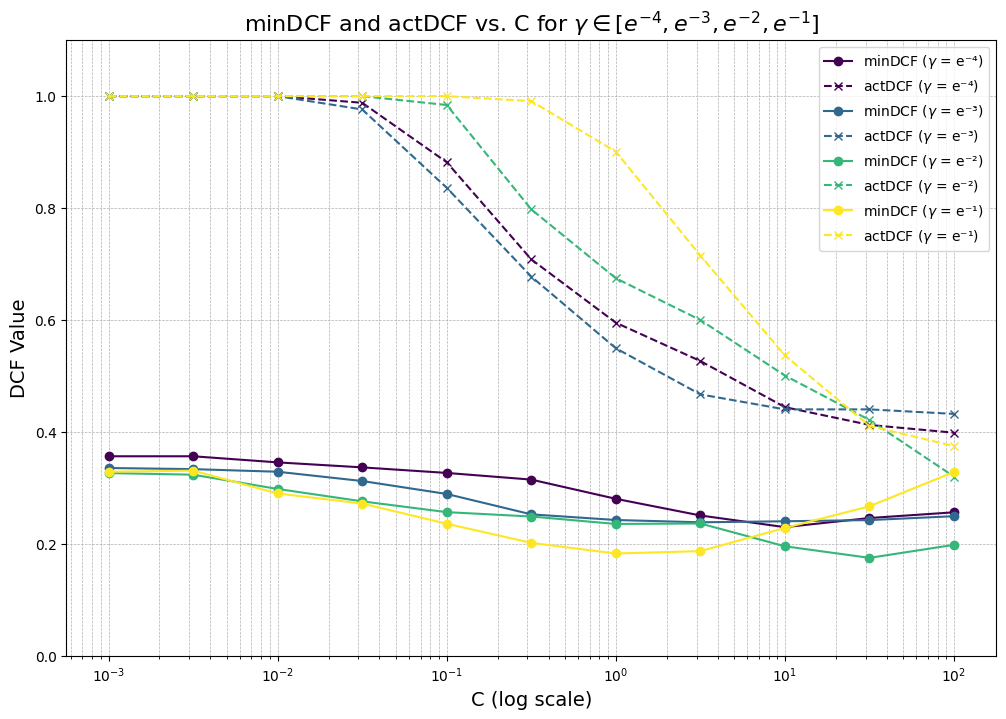

In [16]:
#plot minDCF, actDCF vs C, gamma

import matplotlib.cm as cm #colormaps for better distinguishing of different gammas

gamma_array = np.array(gamma_table)
C_array = np.array(C_table)
minDCF_array = np.array(minDCF_table)
DCF_array = np.array(DCFs_table)

unique_gammas = sorted(list(set(gamma_array))) #e^{-4}, e^{-3}, e^{-2}, e^{-1})
plt.figure(figsize=(12, 8))

colors = cm.viridis(np.linspace(0, 1, len(unique_gammas)))


for i, gamma in enumerate(unique_gammas):
    
    #mask to filter results just for the current gamma
    mask = (gamma_array == gamma)
    
    
    C_for_this_gamma = C_array[mask]
    minDCF_for_this_gamma = minDCF_array[mask]
    DCF_for_this_gamma = DCF_array[mask]
    
    # IMPORTANTE: Ordina i valori in base a C per disegnare una linea pulita
    sort_indices = np.argsort(C_for_this_gamma)
    C_sorted = C_for_this_gamma[sort_indices]
    minDCF_sorted = minDCF_for_this_gamma[sort_indices]
    DCF_sorted = DCF_for_this_gamma[sort_indices]
    
    pretty_label = gamma_label_dict.get(gamma, f"{gamma:.1e}") 
    label_gamma = f"$\gamma$ = {pretty_label}"
    plt.plot(C_sorted, minDCF_sorted, label=f'minDCF ({label_gamma})', marker='o', color=colors[i])
    plt.plot(C_sorted, DCF_sorted, label=f'actDCF ({label_gamma})', marker='x', linestyle='--', color=colors[i])

plt.xscale('log')
plt.xlabel('C (log scale)', fontsize=14)
plt.ylabel('DCF Value', fontsize=14)
plt.title('minDCF and actDCF vs. C for $\gamma \in [e^{-4}, e^{-3}, e^{-2}, e^{-1}]$', fontsize=16)
plt.legend(fontsize=10)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0, 1.1)
plt.show()

## Choosing the best SVM model in terms of $\text{min DCF}$, and plotting its Bayes Error Plot for a wider range of applications

The best model is the **RBF Kernel Soft Margin SVM** having $\gamma = e^{-2} \approx 0.1353$ and $C = 31.6$, achieving a $\text{min DCF} = 0.1755$. We can test how it performs using a **wider range of applications**, so, compute and plot actual and minimum DCF over a wide range of operating points. We can choose prior log odds ranging from -4 to +4:

In [17]:
minDCF_table[31]

0.1754672299027138

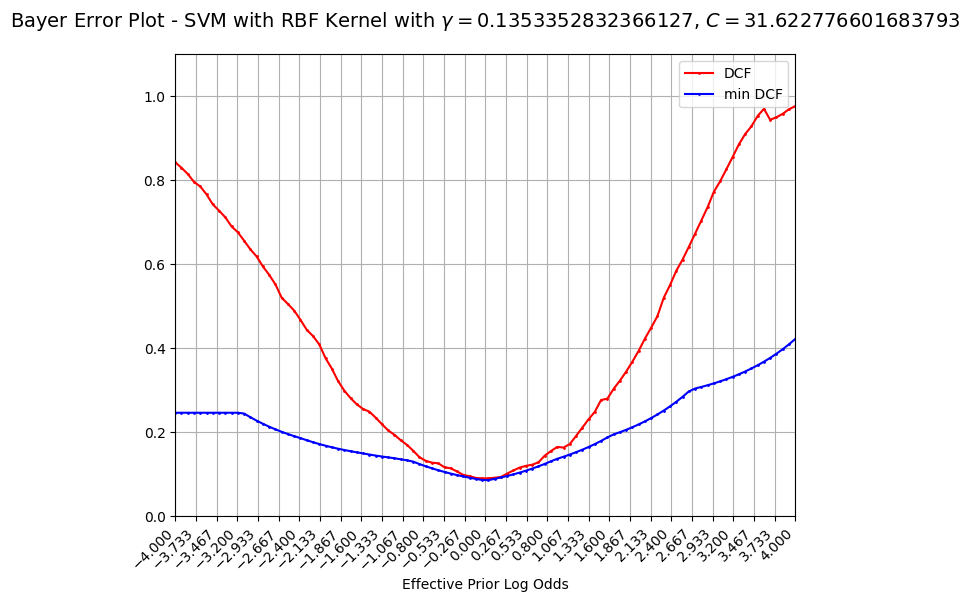

In [18]:
from decisionModelsEvaluation import plotBayesErrorPlots

#find min DCF and corresponding score
minDCF_index = np.argmin(minDCF_table)
scores_best = scoresList[minDCF_index]
gamma_best = gamma_table[minDCF_index]
C_best = C_table[minDCF_index]

def SVM_BayesErrorPlot(scores, LVAL, effPriorLogOdds, title):

    plotBayesErrorPlots(effPriorLogOdds, scores, LVAL, title=title)



SVM_BayesErrorPlot(scores_best, LVAL, np.linspace(-4, 4, 100), f"Bayer Error Plot - SVM with RBF Kernel with $\gamma = {gamma_best}$, $C = {C_best}$")

In [20]:
#save best scores
bestScoresPath = "./best_scores/SVM"

np.save(f"{bestScoresPath}/SVM_RBF_kernel.npy", scores_best)